# How to use the code?


This file contains several examples demonstrating how to use the code to reproduce the plots presented in the report. Brief explanations of the parameters are included. 
For more detailed information about the functions, please refer to the `documentation.md` file.
To see the list of required packages, consult the `requirements.md` file.


In [1]:
from cell_edge_vertex import *
from mesh import *
from additional_functions import *

## Tetrahedron case 

Optimization success: True, Message: `xtol` termination condition is satisfied.
Analytical opening angle: 5.7825391924
Actual opening angle: 5.7826101175


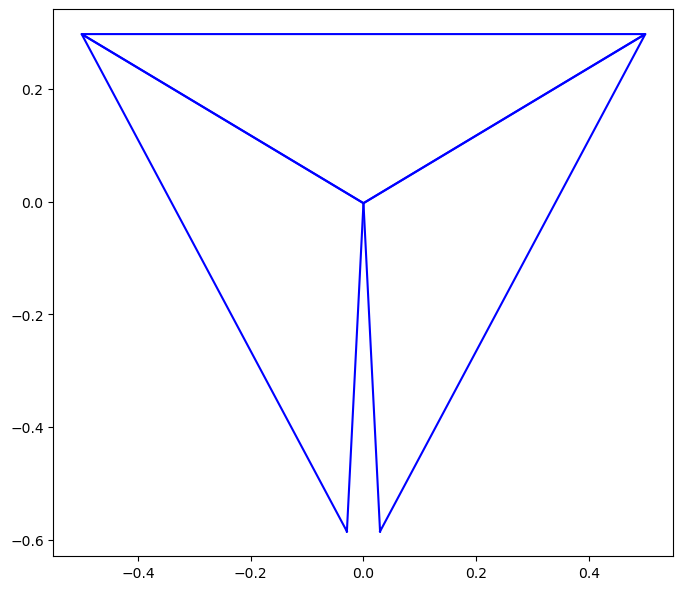

Optimization success: True, Message: `xtol` termination condition is satisfied.
Analytical opening angle: 90.0
Actual opening angle: 89.9998546276


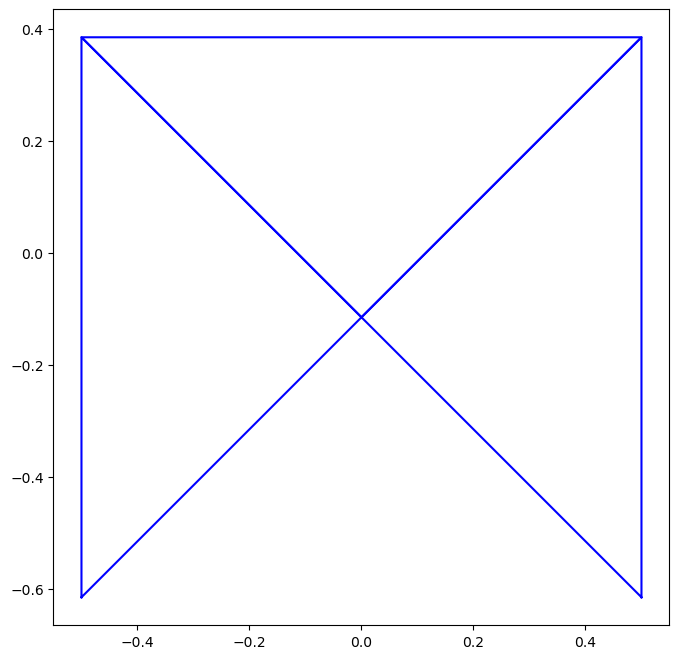

Optimization success: True, Message: `xtol` termination condition is satisfied.
Analytical opening angle: 180.0
Actual opening angle: 179.923152134


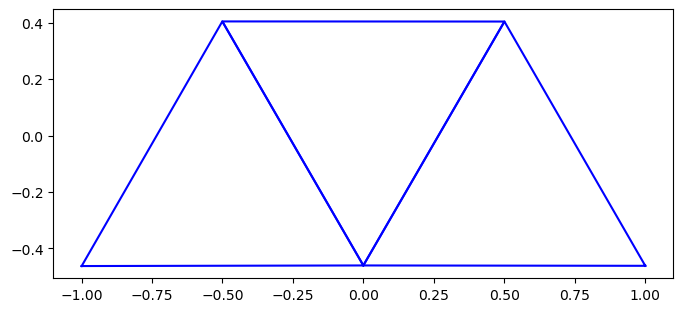

Optimization success: True, Message: `xtol` termination condition is satisfied.
Optimization success: True, Message: `xtol` termination condition is satisfied.
Analytical opening angle: 259.3280707142
Actual opening angle: 259.3279848171


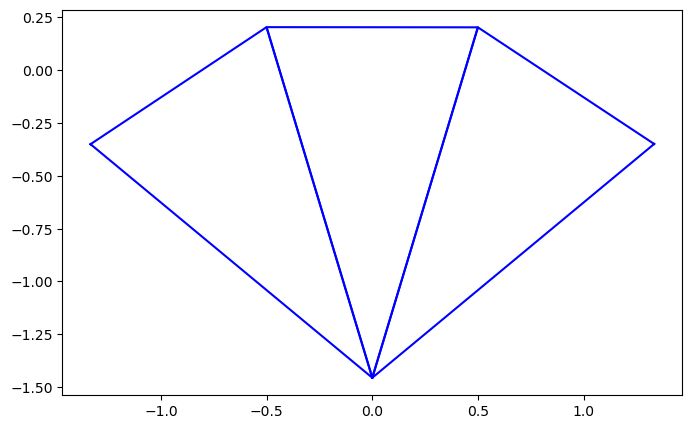

In [2]:
cut=True                            # whether the mesh is cut
mode = "three_triangles"            # always do "three_triangles" for the tetrahedron case
num_cells = 3                       # target number of cells, changing this value whan "three_triangle" has no effect
L0 = 1                              # target final size length for the triangles

h_list = [0.1, 0.5, 1, 2] 
for h_cst in h_list:
    L0 = 1
    h = np.sqrt(2/3)*L0    
    h *= h_cst     # the higher h_cst, the bigger the opening angle

    mesh = Mesh(L0 = L0, mode = mode, cut = cut, num_cells=num_cells)
    mesh.generate()
    if h>np.sqrt(2/3)*L0:
        # ensure the opening exceeds 180 degrees by adjusting central vertex position
        mesh.get_3d_AP(h=np.sqrt(2/3)*L0, L=L0)
        mesh.find_equilibrium(tolerance=1.e-14)         # call the minimization function
        mesh.vertices[1].position = (0, -h)

    mesh.get_3d_AP(h=h, L=L0)
    mesh.find_equilibrium(tolerance=1.e-14)
    mesh.compute_opening_angle(h=h, L=L0)       # computes and prints both the analytical and actual opening angles
    mesh.plot()

## Triple triangles

Optimization success: True, Message: `xtol` termination condition is satisfied.


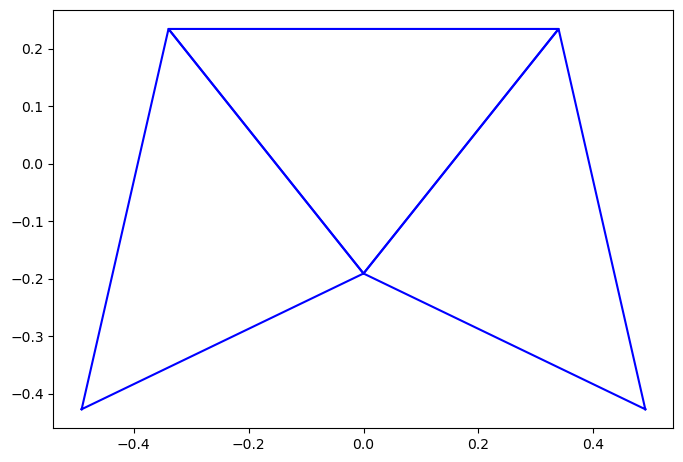

Optimization success: True, Message: `xtol` termination condition is satisfied.


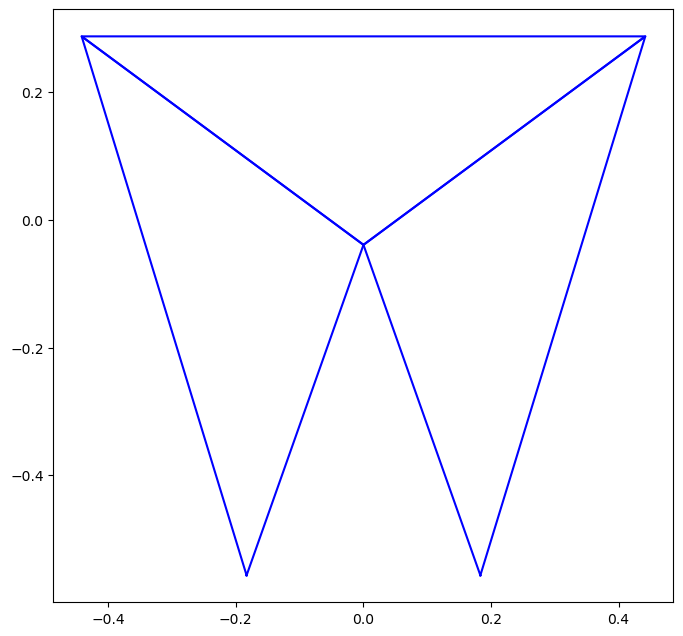

Optimization success: True, Message: `gtol` termination condition is satisfied.


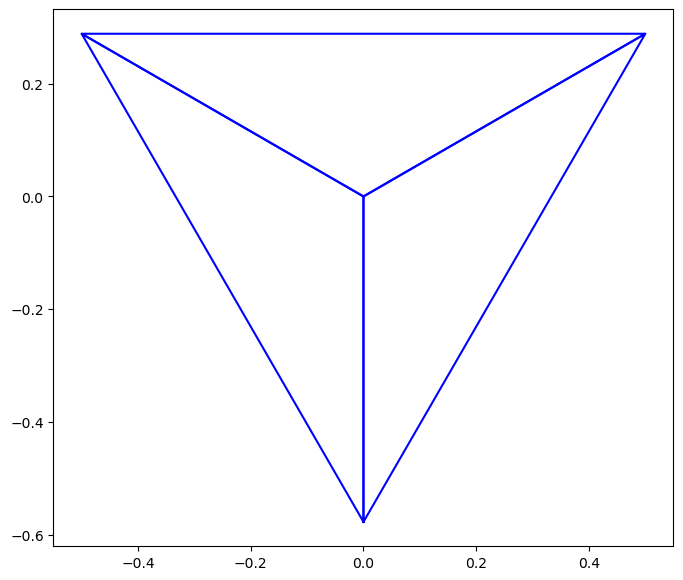

Optimization success: True, Message: `xtol` termination condition is satisfied.


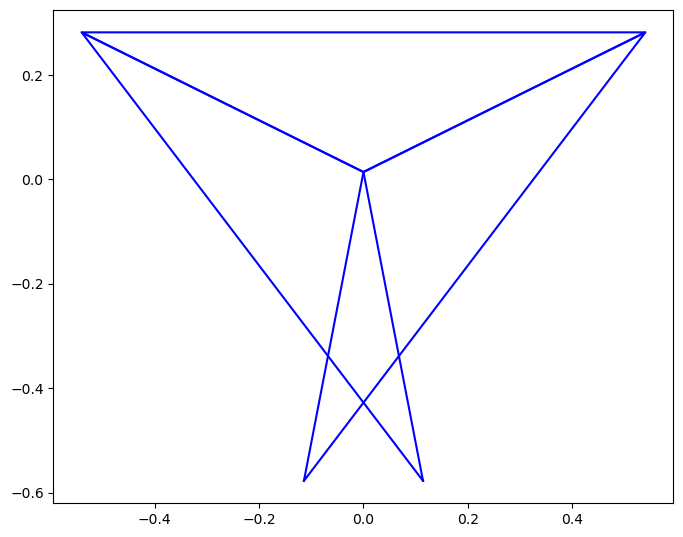

Optimization success: True, Message: `xtol` termination condition is satisfied.


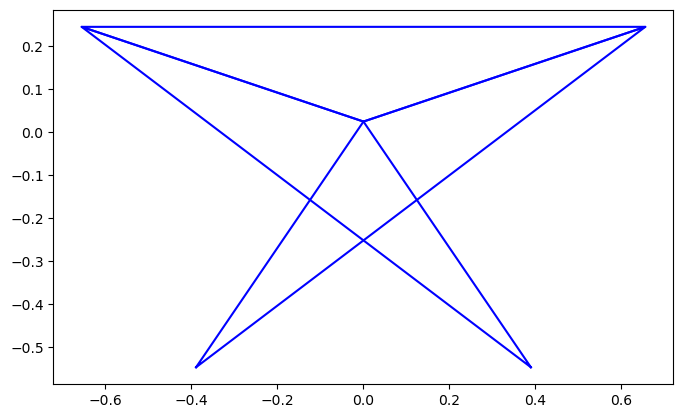

In [3]:
cut=True                            # whether the mesh is cut
mode = "three_triangles"            # always do "three_triangles" for the tetrahedron case
num_cells = 3                       # target number of cells, changing this value whan "three_triangle" has no effect
L0 = 1                              # target final size length for the triangles

S_list = [0.82, 0.92, 1, 1.06, 1.25]
for S in S_list:
    mesh = Mesh(S = S, L0=L0, num_cells=num_cells, mode = mode, cut = cut)
    mesh.generate()
    mesh.find_equilibrium(tolerance=1.e-14)
    mesh.plot()

## Hexagonal mesh with gradient

Optimization success: True, Message: `xtol` termination condition is satisfied.
Current mean force: 0.004925513133804024
Optimization success: True, Message: `xtol` termination condition is satisfied.
Current mean force: 0.00483068489638578


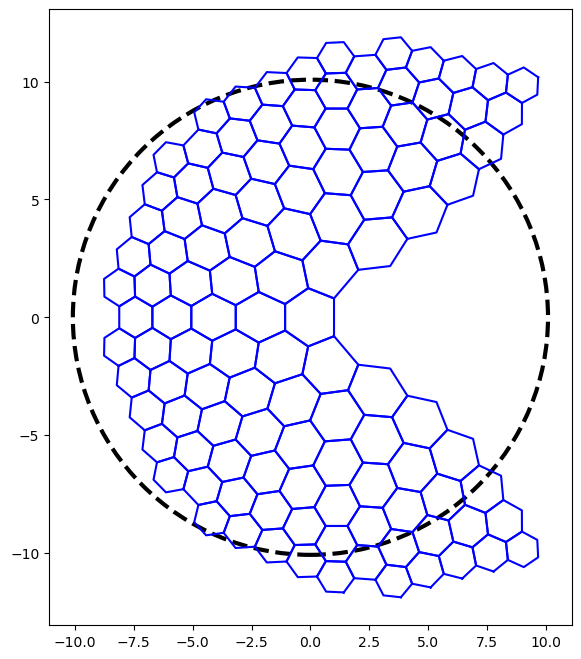

In [4]:
cut = True                 # whether the mesh is cut
grad_S = True              # whether to apply a gradient of incompatibility
grad_L0 = False            # whether to apply a gradient of growth
grad_mode = "center"       # type of gradient to use: "center" or "boundary"
mode = "hexagon"           # use hexagonal cells
num_cells = 100            # number of cells 

S = 0.3                    # target incompatibility value
L0 = 1.3                   # target edge length for the hexagons

# create and initialize the mesh
mesh = Mesh(num_cells=num_cells, S=S, L0=L0, mode=mode, cut=cut, grad_S=grad_S, grad_L0=grad_L0, grad_mode=grad_mode)

# find the equilibrium
# uses the mixed approach combining minimization and explicit Euler 
mesh.equilibrium()

# plot the mesh
mesh.plot()


## Incompatibility on a sphere

Min incompatibility: 3.7224194364083982, Max incompatibility: 4.994870193473511


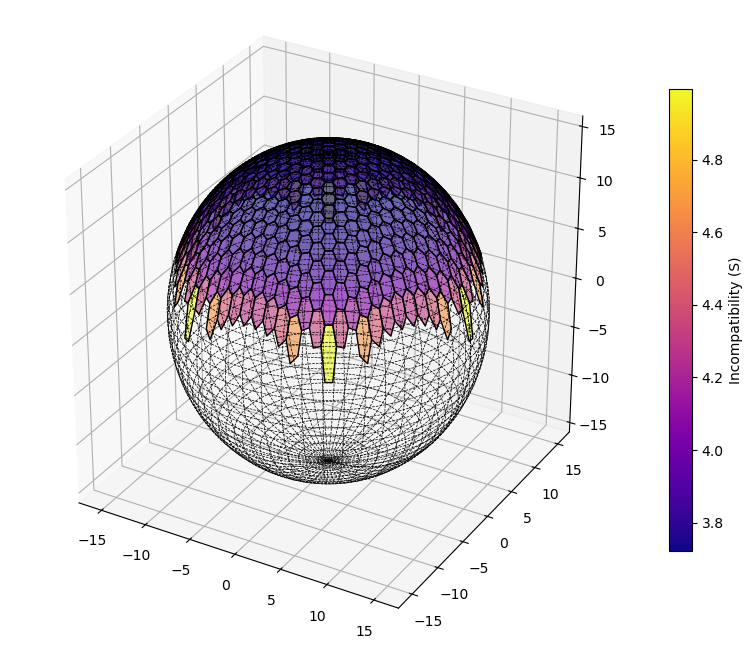

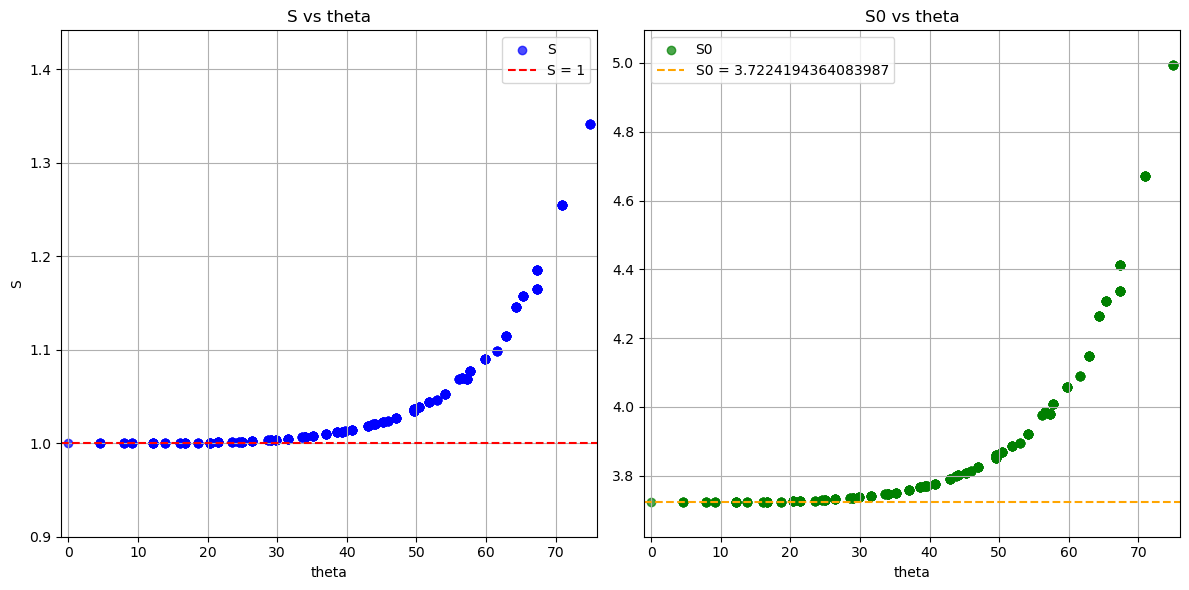

In [5]:
num_cells = 500               # number of cells (2000 in the report)
folder_name = "S0_dome_hexagon"  # folder to save simulation outputs

# generate the dome, compute all S0 values and save the results 
S0_with_dome_hexagon(num_cells=num_cells, folder_name=folder_name)

## Spherical cap flattening

In [6]:
num_cells = 100                      # number of cells (500 in the report)
folder_name = "Spherical_cap"        # folder to save output data
mode = "triangle"                    # type of cells to use: "triangle" or "hexagon"
cut = True                           # whether the mesh is cut

# list of rho scaling constants to test in the dome fitting
# a value of 1 corresponds to a half sphere, larger values produce smaller caps
rho_cst_list = [2, 1.5, 1.3, 1.1, 1.05]

# run the simulation for each value of rho
# saves the initial flat mesh, the spherical cap, and the final flat mesh
# also saves the fitted values, coordinates of vertices on the cut, and the final mesh with the fit
gradual_fit_dome(rho_cst_list, num_cells=num_cells, folder_name=folder_name, cut=cut, mode=mode)


Plot saved to c:\Users\berti\OneDrive\Documents\CMB\Stage M2\simple_model\Vertex_model\Spherical_cap\cut_52cells_1.00alpha_1.00beta_0.00gamma_1.000S0_1.000L0_None.png
Plot saved to c:\Users\berti\OneDrive\Documents\CMB\Stage M2\simple_model\Vertex_model\Spherical_cap\41.410theta_1alpha_1beta_M3.png
Optimization success: True, Message: `xtol` termination condition is satisfied.
Current mean force: 0.0007974031256622589
Optimization success: True, Message: `xtol` termination condition is satisfied.
Current mean force: 0.0007790799775034566
Optimization success: True, Message: `xtol` termination condition is satisfied.
Current mean force: 0.0007611880099999121
Optimization success: False, Message: The maximum number of function evaluations is exceeded.
Current mean force: 0.00020471498202932853
Optimization success: True, Message: `xtol` termination condition is satisfied.
Current mean force: 0.00019210983413598577
Optimization success: True, Message: `xtol` termination condition is satis

## Cone flattening

In [7]:

num_cells = 100             # number of cells 
theta = 90                  # cone target opening angle in degrees
folder_name = "Cone"        # folder to save simulation outputs
mode = "triangle"           # type of cells to use: "triangle" or "hexagon"
cut = True                  # whether the mesh is cut

# run the cone flattening simulation with the specified parameters
# saves the cone and the final flat mesh
do_cone(num_cells=num_cells, cut=cut, theta=theta, mode=mode, folder_name=folder_name)

Min incompatibility: 4.560885707805924, Max incompatibility: 7.473803811385515
Plot saved to c:\Users\berti\OneDrive\Documents\CMB\Stage M2\simple_model\Vertex_model\Cone\90.000theta_1alpha_1beta_M3.png
Optimization success: True, Message: `xtol` termination condition is satisfied.
Current mean force: 2.7553015399390224e-05
Optimization success: True, Message: `xtol` termination condition is satisfied.
Current mean force: 2.6479649451427053e-05
Optimization success: True, Message: `xtol` termination condition is satisfied.
Current mean force: 2.5380789582593512e-05
Optimization success: True, Message: `xtol` termination condition is satisfied.
Current mean force: 2.4297681841746853e-05
Optimization success: True, Message: `xtol` termination condition is satisfied.
Current mean force: 2.329567124004806e-05
Optimization success: True, Message: `xtol` termination condition is satisfied.
Current mean force: 2.2440501189251747e-05
Optimization success: True, Message: `xtol` termination cond